### Analysis and Results of the Preprocessing Steps

1. Black Edge Removal
2. Rolling Ball 
3. RL

In [1]:
# imports
from pathlib import Path
BASE_DIR = Path.cwd().parent
import stackview
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util) #good for all my deblurring approaches
import numpy as np
import matplotlib.pyplot as plt
import sys
project_root = Path().resolve().parent
sys.path.append(str(project_root))
# python files
import src.preprocessing as preproc

In [3]:
# read in the preprocessed image
# preprocessed_image = io.imread(BASE_DIR / 'data/preprocessed_images/background_subtracted_rolling_full_radius7.tiff')
original_image = io.imread(BASE_DIR / 'data/raw/corrected_image/cnx43.tif')


FileNotFoundError: [Errno 2] No such file or directory: '/home/rck292/Project/data/raw/corrected_image/cnx43.tif'

### 1. Black Edge Removal

In [ ]:
# img = imread(image_path, cv2.IMREAD_GRAYSCALE)
# get the image shape
# h, w = original_image[10].shape

In [15]:
stackview.imshow(original_image[10][0:15, :])

In [ ]:
original_image[:,15:, :].sum()

In [58]:
# reduce the image
original_image_reduced = original_image[:,15:, :]

In [7]:
from skimage.restoration import rolling_ball

In [21]:
original_image_reduced.shape

(510, 2033, 1012)

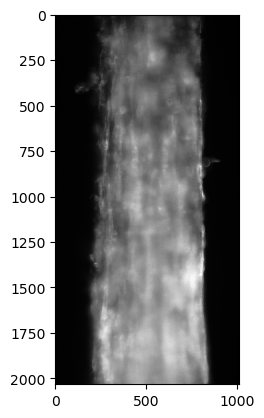

In [27]:
stackview.imshow(original_image_reduced[255], axes=True)

In [90]:
background_rolling = rolling_ball(original_image_reduced[100], radius=10) #radius is the region looked at when determining what is background. It should be bigger than a connexin plaque so 30-50px 2.9 s per slide -> 290s per 100 slide = ca. 5 min for 100 slides
# stackview.imshow(background_rolling, axes=True, title='Rolling Ball Background')
background_subtracted_rolling = original_image_reduced[100] - background_rolling

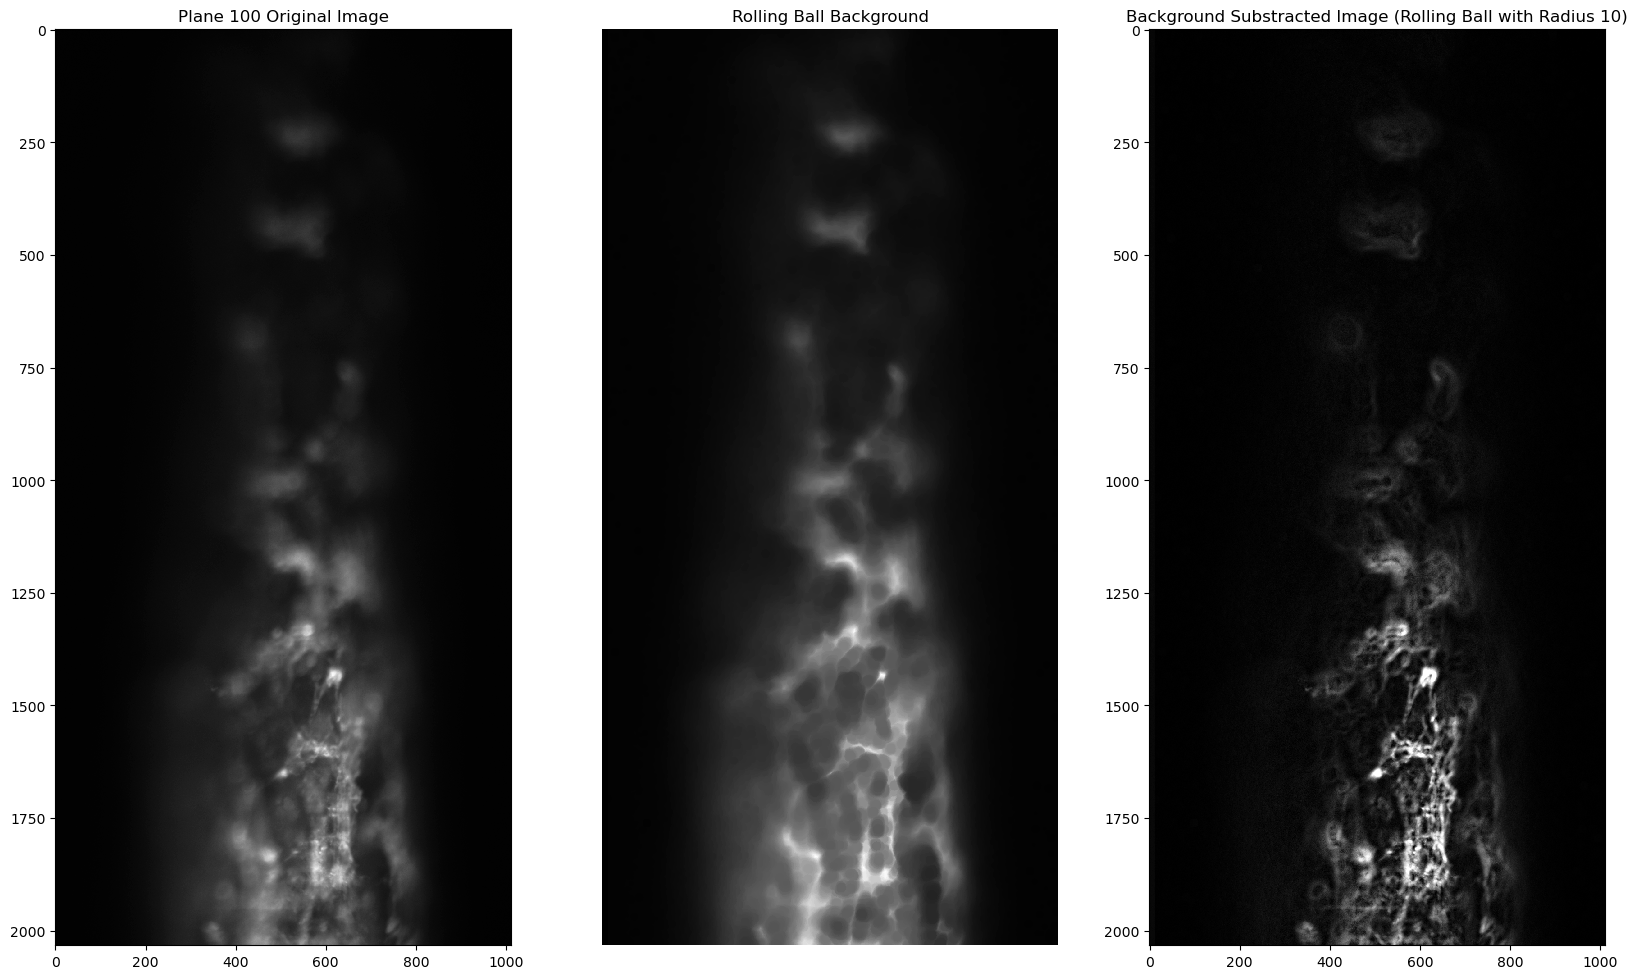

In [91]:
fig, axs = plt.subplots(1, 3, figsize=(20,20))

stackview.imshow(original_image_reduced[100], plot=axs[0], title = "Plane 100 Original Image", axes=True)
stackview.imshow(background_rolling, plot=axs[1], title='Rolling Ball Background')
stackview.imshow(background_subtracted_rolling,plot = axs[2], title = "Background Substracted Image (Rolling Ball with Radius 10)", max_display_intensity=5000, axes=True)

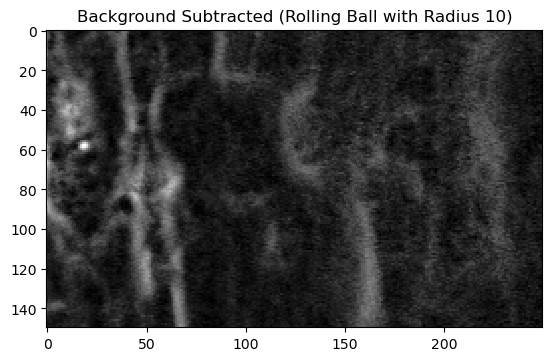

In [68]:
stackview.imshow(background_subtracted_rolling[1000:1150,250:500], axes=True, title='Background Subtracted (Rolling Ball with Radius 10)')

In [ ]:
# huygens_image = io.imread(BASE_DIR / 'data/test_plane_254.tiff')

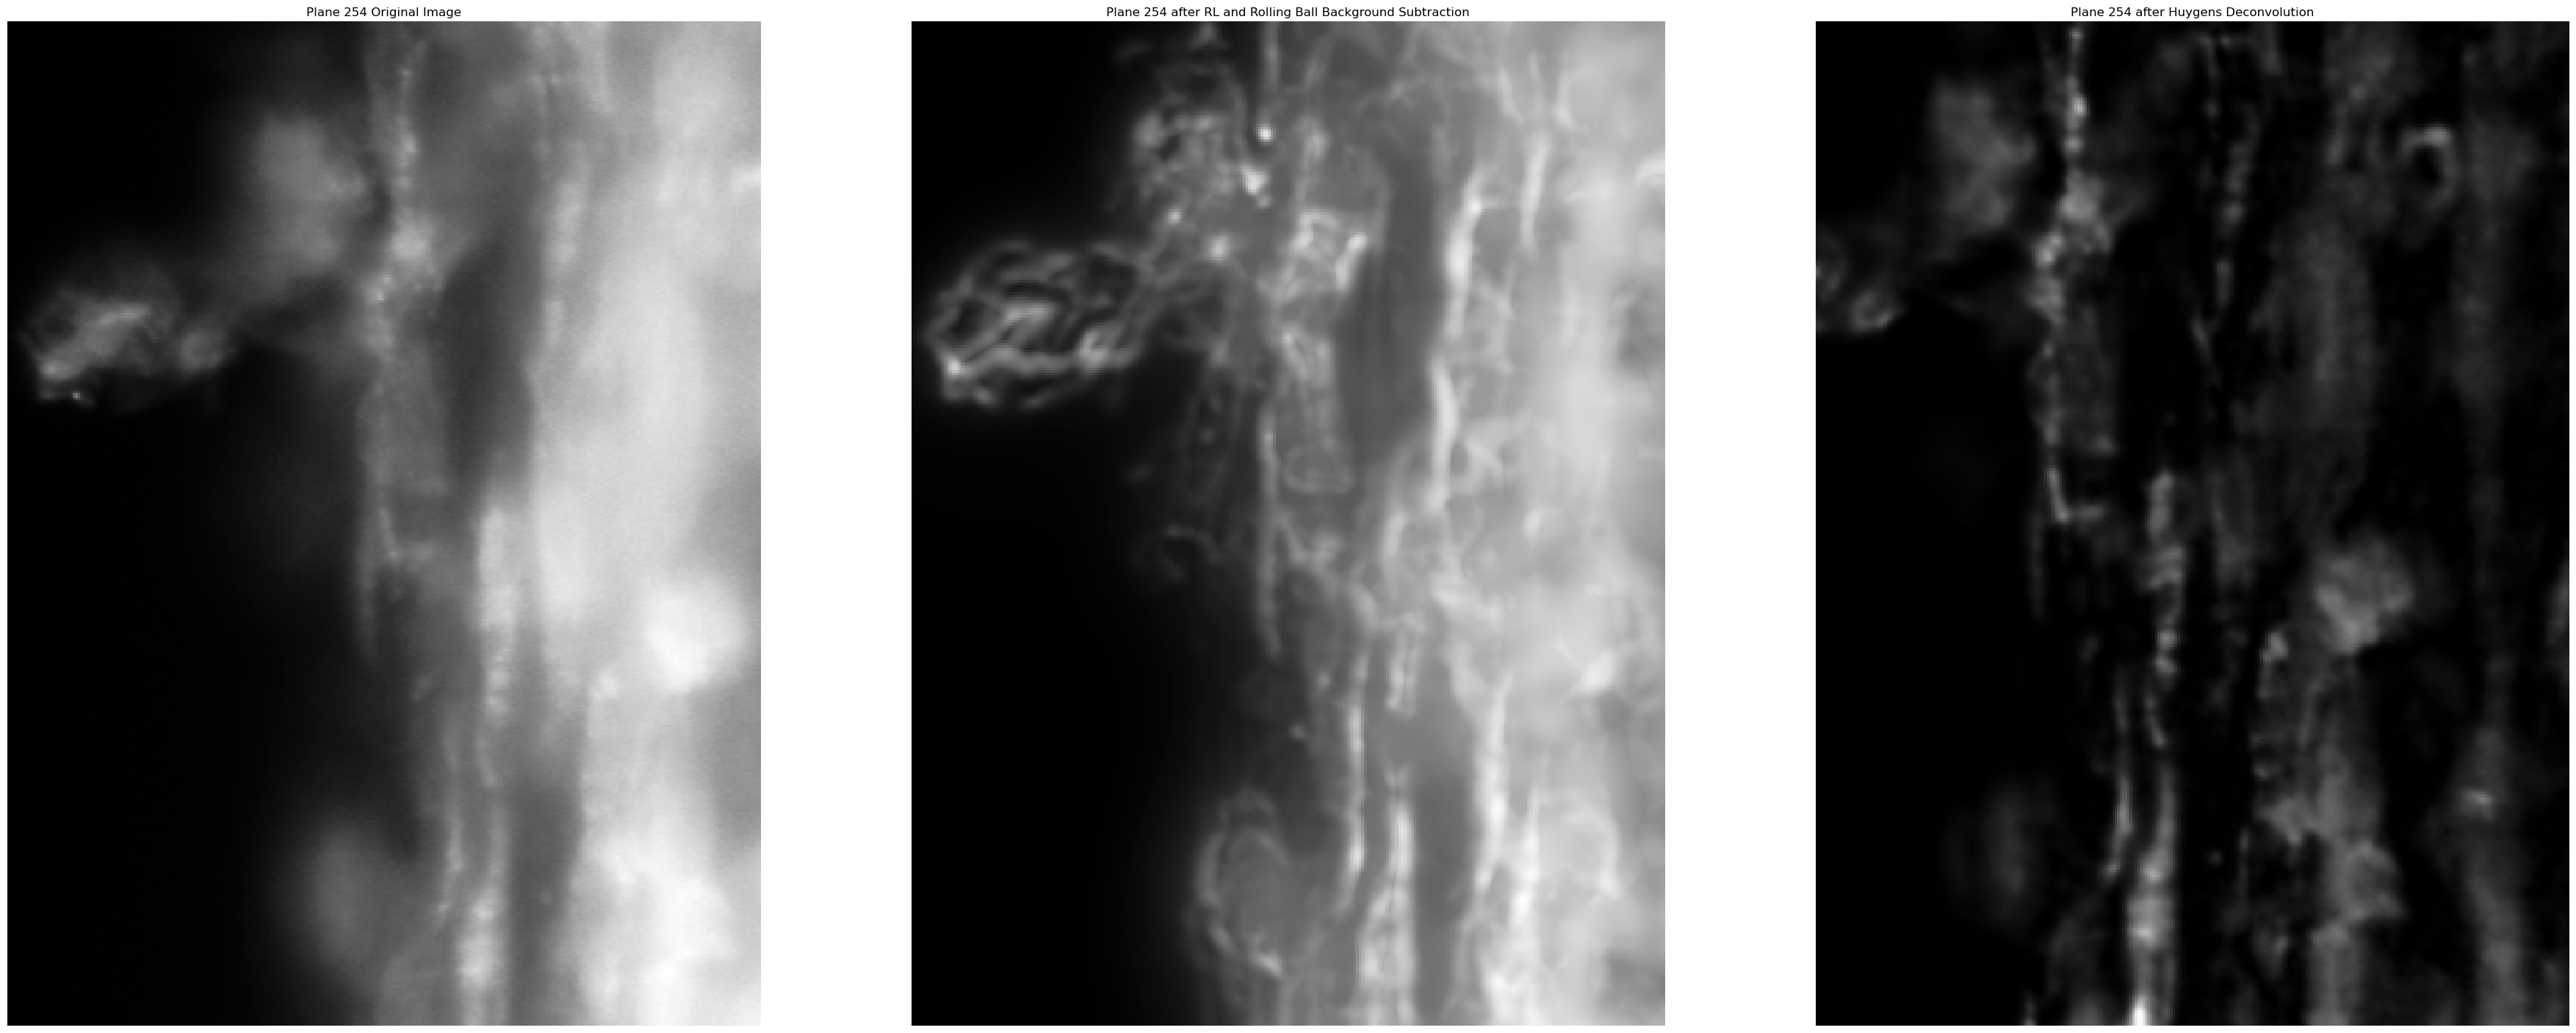

In [30]:
fig, axs = plt.subplots(1, 3, figsize=(45,20))

stackview.imshow(original_image[254][300:700,100:400], plot=axs[0], title = "Plane 254 Original Image")
stackview.imshow(preprocessed_image[254][300:700,100:400],plot = axs[1], title = "Plane 254 after RL and Rolling Ball Background Subtraction")
stackview.imshow(huygens_image[300:700,100:400], plot=axs[2], title = "Plane 254 after Huygens Deconvolution")